# 04 — Uplift Model (T-Learner & X-Learner)
Four variants: TabPFN T-Learner, TabICL T-Learner, TabPFN X-Learner, TabICL X-Learner.
ITE = E[Y(0)|X] - E[Y(1)|X]  (positive = outreach reduces churn).


In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from tabpfn import TabPFNClassifier
from tabicl import TabICLClassifier
from feature_engineering import FEATURE_COLS
sns.set_style('whitegrid')
np.random.seed(42)


In [2]:
train = pd.read_parquet('train_features.parquet')
trim  = pd.read_parquet('trim_mask.parquet')
train = train.merge(trim, on='member_id')
df = train[train['in_support']].copy().reset_index(drop=True)
print(f"In-support members: {len(df):,}")
print(f"Treated: {df['outreach'].sum():,}  Control: {(1-df['outreach']).sum():,}")

X  = df[FEATURE_COLS].values.astype(float)
T  = df['outreach'].values
Y  = df['churn'].values
ps = df['propensity'].values

X1 = X[T==1];  Y1 = Y[T==1]
X0 = X[T==0];  Y0 = Y[T==0]
print(f"Treated shape: {X1.shape}  Control shape: {X0.shape}")


In-support members: 10,000
Treated: 3,984  Control: 6,016
Treated shape: (3984, 14)  Control shape: (6016, 14)


In [3]:
def make_tabpfn():
    return TabPFNClassifier(n_estimators=8, random_state=42)

def make_tabicl():
    return TabICLClassifier(random_state=42)

def t_learner(make_model, X, T, Y, X_test):
    """T-Learner: fit mu0 on control, mu1 on treated, ITE = mu0(x) - mu1(x)."""
    X1, Y1 = X[T==1], Y[T==1]
    X0, Y0 = X[T==0], Y[T==0]
    m1 = make_model(); m1.fit(X1, Y1)
    m0 = make_model(); m0.fit(X0, Y0)
    mu1 = m1.predict_proba(X_test)[:, 1]
    mu0 = m0.predict_proba(X_test)[:, 1]
    return mu0 - mu1   # positive = outreach reduces churn

def x_learner(make_model, X, T, Y, ps, X_test, ps_test):
    """X-Learner: cross-impute pseudo-outcomes, weight by propensity."""
    X1, Y1 = X[T==1], Y[T==1]
    X0, Y0 = X[T==0], Y[T==0]

    # Stage 1: outcome models
    m1 = make_model(); m1.fit(X1, Y1)
    m0 = make_model(); m0.fit(X0, Y0)

    # Stage 2: pseudo-outcomes
    d1 = Y1 - m0.predict_proba(X1)[:, 1]   # effect on treated
    d0 = m1.predict_proba(X0)[:, 1] - Y0   # effect on control

    # Stage 3: effect models
    e1 = make_model(); e1.fit(X1, (d1 > 0).astype(int))
    e0 = make_model(); e0.fit(X0, (d0 > 0).astype(int))
    # Use sign+magnitude via proba - 0.5 trick scaled by original range
    tau1 = e1.predict_proba(X_test)[:, 1] * 2 - 1  # maps [0,1] -> [-1,1]
    tau0 = e0.predict_proba(X_test)[:, 1] * 2 - 1

    # Weight by 1-ps for treated, ps for control (standard X-learner weighting)
    tau = (1 - ps_test) * tau1 + ps_test * tau0
    return tau

print("Helper functions defined.")


Helper functions defined.


In [4]:
# ── T-Learner with TabPFN ──────────────────────────────────────────────────
print("Fitting T-Learner (TabPFN)...")
ite_tpfn_t = t_learner(make_tabpfn, X, T, Y, X)
print(f"ITE stats: mean={ite_tpfn_t.mean():.4f}, std={ite_tpfn_t.std():.4f}, "
      f"min={ite_tpfn_t.min():.4f}, max={ite_tpfn_t.max():.4f}")
print(f"% persuadable (ITE>0): {(ite_tpfn_t>0).mean():.2%}")


Fitting T-Learner (TabPFN)...


ITE stats: mean=0.0355, std=0.0385, min=-0.2272, max=0.1911
% persuadable (ITE>0): 85.90%


In [5]:
# ── T-Learner with TabICL ──────────────────────────────────────────────────
print("Fitting T-Learner (TabICL)...")
ite_ticl_t = t_learner(make_tabicl, X, T, Y, X)
print(f"ITE stats: mean={ite_ticl_t.mean():.4f}, std={ite_ticl_t.std():.4f}, "
      f"min={ite_ticl_t.min():.4f}, max={ite_ticl_t.max():.4f}")
print(f"% persuadable (ITE>0): {(ite_ticl_t>0).mean():.2%}")


Fitting T-Learner (TabICL)...


ITE stats: mean=0.0341, std=0.0417, min=-0.2243, max=0.2487
% persuadable (ITE>0): 81.45%


In [6]:
# ── X-Learner with TabPFN ──────────────────────────────────────────────────
print("Fitting X-Learner (TabPFN)...")
ite_tpfn_x = x_learner(make_tabpfn, X, T, Y, ps, X, ps)
print(f"ITE stats: mean={ite_tpfn_x.mean():.4f}, std={ite_tpfn_x.std():.4f}, "
      f"min={ite_tpfn_x.min():.4f}, max={ite_tpfn_x.max():.4f}")
print(f"% persuadable (ITE>0): {(ite_tpfn_x>0).mean():.2%}")


Fitting X-Learner (TabPFN)...


ITE stats: mean=-0.1978, std=0.1929, min=-0.8177, max=0.3036
% persuadable (ITE>0): 15.25%


In [7]:
# ── X-Learner with TabICL ──────────────────────────────────────────────────
print("Fitting X-Learner (TabICL)...")
ite_ticl_x = x_learner(make_tabicl, X, T, Y, ps, X, ps)
print(f"ITE stats: mean={ite_ticl_x.mean():.4f}, std={ite_ticl_x.std():.4f}, "
      f"min={ite_ticl_x.min():.4f}, max={ite_ticl_x.max():.4f}")
print(f"% persuadable (ITE>0): {(ite_ticl_x>0).mean():.2%}")


Fitting X-Learner (TabICL)...


ITE stats: mean=-0.1928, std=0.1946, min=-0.8121, max=0.3093
% persuadable (ITE>0): 16.45%


In [8]:
# Ensemble: average all 4 ITE estimates
ite_ensemble = (ite_tpfn_t + ite_ticl_t + ite_tpfn_x + ite_ticl_x) / 4
print(f"Ensemble ITE: mean={ite_ensemble.mean():.4f}, std={ite_ensemble.std():.4f}")
print(f"% persuadable: {(ite_ensemble>0).mean():.2%}")

df['ite_tpfn_t'] = ite_tpfn_t
df['ite_ticl_t'] = ite_ticl_t
df['ite_tpfn_x'] = ite_tpfn_x
df['ite_ticl_x'] = ite_ticl_x
df['ite_ensemble'] = ite_ensemble


Ensemble ITE: mean=-0.0802, std=0.0934
% persuadable: 20.31%


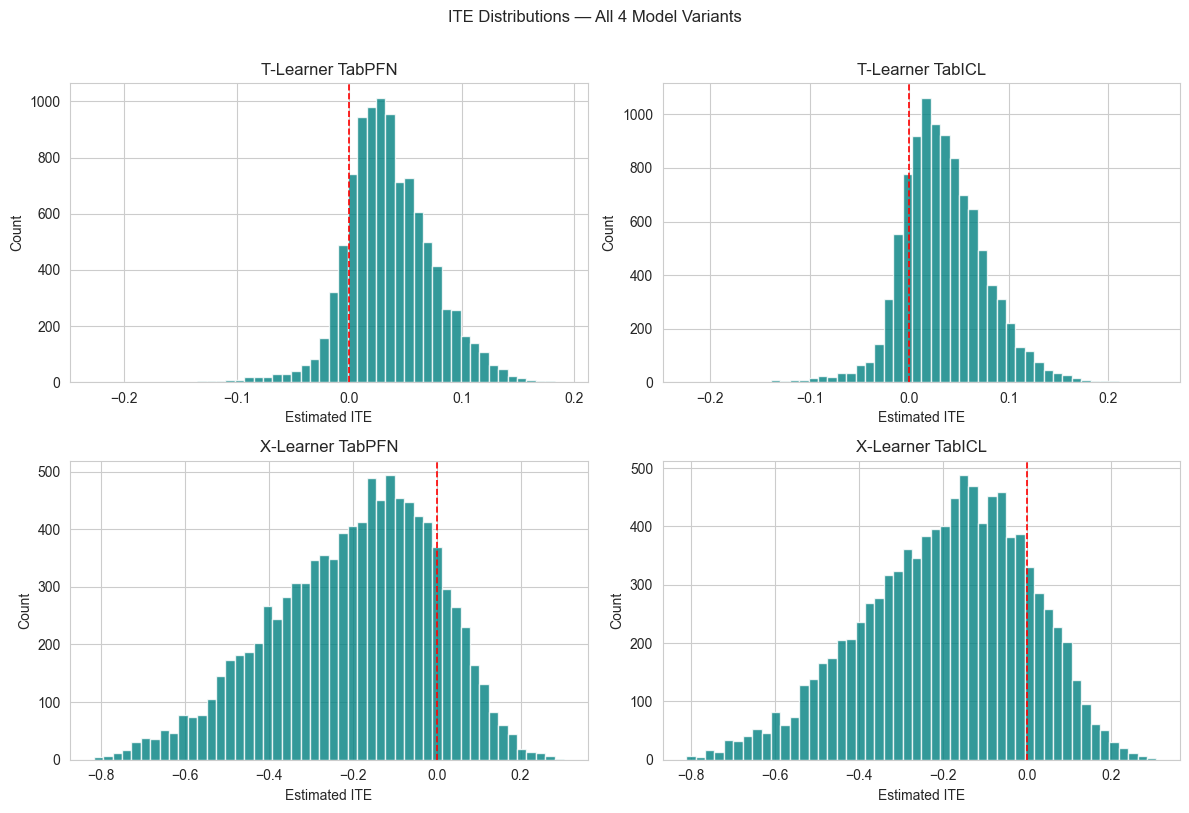

In [9]:
# ITE distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
models = [('ite_tpfn_t','T-Learner TabPFN'),('ite_ticl_t','T-Learner TabICL'),
          ('ite_tpfn_x','X-Learner TabPFN'),('ite_ticl_x','X-Learner TabICL')]
for ax, (col, title) in zip(axes.flatten(), models):
    ax.hist(df[col], bins=50, color='teal', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', ls='--', lw=1.2)
    ax.set_title(title)
    ax.set_xlabel('Estimated ITE')
    ax.set_ylabel('Count')
plt.suptitle('ITE Distributions — All 4 Model Variants', y=1.01)
plt.tight_layout()
plt.savefig('ite_distributions.png', bbox_inches='tight')
plt.show()


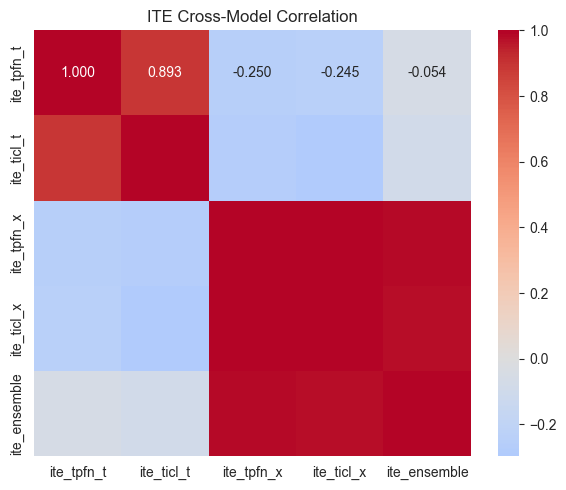

              ite_tpfn_t  ite_ticl_t  ite_tpfn_x  ite_ticl_x  ite_ensemble
ite_tpfn_t         1.000       0.893      -0.250      -0.245        -0.054
ite_ticl_t         0.893       1.000      -0.262      -0.297        -0.086
ite_tpfn_x        -0.250      -0.262       1.000       0.995         0.980
ite_ticl_x        -0.245      -0.297       0.995       1.000         0.977
ite_ensemble      -0.054      -0.086       0.980       0.977         1.000


In [10]:
# Cross-model agreement
corr_matrix = df[['ite_tpfn_t','ite_ticl_t','ite_tpfn_x','ite_ticl_x','ite_ensemble']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, annot_kws={'size':10})
ax.set_title('ITE Cross-Model Correlation')
plt.tight_layout()
plt.savefig('ite_model_agreement.png', bbox_inches='tight')
plt.show()
print(corr_matrix.round(3))


In [11]:
# Persuadable profile: top 20% ITE vs bottom 20%
df['ite_rank'] = df['ite_ensemble'].rank(ascending=False)
top = df[df['ite_rank'] <= len(df)*0.2]
bot = df[df['ite_rank'] > len(df)*0.8]

profile = pd.DataFrame({
    'top_persuadable': top[FEATURE_COLS + ['churn']].mean(),
    'bottom_persuadable': bot[FEATURE_COLS + ['churn']].mean()
})
profile['diff'] = profile['top_persuadable'] - profile['bottom_persuadable']
print("Profile: top-20% ITE vs bottom-20% ITE")
print(profile.sort_values('diff', key=abs, ascending=False).round(3))


Profile: top-20% ITE vs bottom-20% ITE
                       top_persuadable  bottom_persuadable    diff
tenure_days                    276.146             357.580 -81.434
app_sessions                     5.121              14.702  -9.580
app_sessions_last7d              2.523               7.479  -4.956
days_since_wellco                3.746               2.166   1.580
days_since_app                   2.042               0.478   1.563
wellco_visits                   10.004              11.566  -1.562
total_visits                    26.088              25.606   0.481
unique_wellco_domains            3.230               3.424  -0.195
churn                            0.244               0.122   0.122
health_content_ratio             0.359               0.428  -0.070
expected_icd_count               1.774               1.814  -0.039
icd_Z71_3                        0.583               0.612  -0.030
unexpected_icd_count             2.885               2.869   0.016
icd_E11_9              

In [12]:
# Now predict ITE for test set — fit final models on FULL train
test = pd.read_parquet('test_features.parquet')
X_test = test[FEATURE_COLS].values.astype(float)

# We need propensity for X-learner test predictions — fit propensity on full train
from tabpfn import TabPFNClassifier as TPFN
ps_model = TPFN(n_estimators=8, random_state=42)
ps_model.fit(X, T)
ps_test = ps_model.predict_proba(X_test)[:, 1]

print("Predicting ITE on test set (4 models)...")
ite_test_tpfn_t = t_learner(make_tabpfn, X, T, Y, X_test)
ite_test_ticl_t = t_learner(make_tabicl, X, T, Y, X_test)
ite_test_tpfn_x = x_learner(make_tabpfn, X, T, Y, ps, X_test, ps_test)
ite_test_ticl_x = x_learner(make_tabicl, X, T, Y, ps, X_test, ps_test)
ite_test_ensemble = (ite_test_tpfn_t + ite_test_ticl_t + ite_test_tpfn_x + ite_test_ticl_x) / 4

test['ite_tpfn_t']   = ite_test_tpfn_t
test['ite_ticl_t']   = ite_test_ticl_t
test['ite_tpfn_x']   = ite_test_tpfn_x
test['ite_ticl_x']   = ite_test_ticl_x
test['ite_ensemble'] = ite_test_ensemble
test['propensity']   = ps_test
print(f"Test ITE ensemble: mean={ite_test_ensemble.mean():.4f}, std={ite_test_ensemble.std():.4f}")
print(f"% persuadable on test: {(ite_test_ensemble>0).mean():.2%}")


Predicting ITE on test set (4 models)...


Test ITE ensemble: mean=-0.0805, std=0.0946
% persuadable on test: 20.38%


In [13]:
test.to_parquet('test_predictions.parquet', index=False)
print("Saved test_predictions.parquet")


Saved test_predictions.parquet
